In [59]:
# Importing dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score,ConfusionMatrixDisplay, roc_auc_score

In [3]:
# Loading the dataset
df_original = pd.read_csv("D:/Python programming/Projects/Sentiment Analysis- US Airline Reviews/dataset/tweets.csv")
df = df_original[["text", "airline_sentiment"]]

In [4]:
df.sample(5)

,text,airline_sentiment
7113,“@JetBlue: Our fleet's on fleek. http://t.co/M...,neutral
13263,@AmericanAir SJC-&gt;LAX. After the fourth tim...,negative
7195,"@JetBlue Called JB 3 times!Everytime, Auto Vm...",negative
12871,@AmericanAir boom. http://t.co/PzGc6Jch7n,neutral
14176,"@AmericanAir My baggage is lost, my flight Can...",negative


## Text Preprocessing

In [5]:
# Checking for null values
df.isnull().sum()

text                 0
airline_sentiment    0
dtype: int64

In [6]:
# Checking duplicates
print(f"Number of duplicates {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Duplicates has been removed")
print(f"Number of duplicates {df.duplicated().sum()}")

Number of duplicates 188
Duplicates has been removed
Number of duplicates 0


#### Text Cleaning

In [7]:
# ------------------------------------------------------------
# Text preprocessing function
# ------------------------------------------------------------

negative_contractions = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "haven't": "have not", "hasn't": "has not",
    "hadn't": "had not", "won't": "will not", "wouldn't": "would not",
    "can't": "cannot", "couldn't": "could not", "shouldn't": "should not",
    "mustn't": "must not", "mightn't": "might not", "needn't": "need not"}


def preprocess_text(text):
    text = text.lower()

    # Expand negative contractions to preserve explicit negation.
    for contraction, expansion in negative_contractions.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', expansion, text)

    # Remove email addresses because they mainly contain contact information.
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove URLs because they generally provide little sentiment information.
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Remove HTML entities such as &amp;, &quot; and &nbsp;.
    text = re.sub(r'&[a-zA-Z0-9#]+;', ' ', text)

    # Remove only the "#" symbol while keeping the hashtag text.
    text = re.sub(r'#', '', text)

    # Remove emojis because we decided to keep the initial
    emoji_pattern = re.compile(
        "[" 
        "\U0001F300-\U0001F5FF"
        "\U0001F600-\U0001F64F"
        "\U0001F680-\U0001F6FF"
        "\U0001F700-\U0001F77F"
        "\U0001F780-\U0001F7FF"
        "\U0001F800-\U0001F8FF"
        "\U0001F900-\U0001F9FF"
        "\U0001FA00-\U0001FAFF"
        "\U00002600-\U000026FF"
        "\U00002700-\U000027BF"
        "]+",
        flags=re.UNICODE
    )
    text = emoji_pattern.sub(' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation and special characters.
    text = re.sub(r'[^\w\s]', ' ', text)

    # Normalize repeated characters such as "goooood" → "good" and "soooo" → "soo".
    text = re.sub(r'([a-z])\1{2,}', r'\1\1', text)

    # Remove extra whitespace created during preprocessing.
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [8]:
# Text cleaning
df["clean_text"] = df["text"].fillna("").apply(preprocess_text)

pd.set_option('display.max_colwidth', None)

comparison = df[["text", "clean_text"]].sample(5, random_state=41)

display(comparison)

,text,clean_text
8616,@JetBlue The Magic eight ball has never steered me wrong :),jetblue the magic eight ball has never steered me wrong
3479,@united Thank you! Off to LA to do something very special.,united thank you off to la to do something very special
5631,@SouthwestAir Apparently mechanics had to be flown in to fix some planes...not the most assuring sign,southwestair apparently mechanics had to be flown in to fix some planes not the most assuring sign
8959,@JetBlue sitting on the plane in JFK waiting to take off doors are open catering is stocking up we are delayed but they couldn't be nicer,jetblue sitting on the plane in jfk waiting to take off doors are open catering is stocking up we are delayed but they could not be nicer
7120,Do less please @JetBlue,do less please jetblue


#### Target Variable Encoding

In [9]:
# Encoding the target variable
le = LabelEncoder()
df["airline_sentiment_encoded"] = le.fit_transform(df["airline_sentiment"])
print(df.airline_sentiment_encoded.unique())

[1 2 0]


In [10]:
print("Encoded Labels:")
print(f"0 -> Negative, 1 -> Netral, 2 -> Positive")

Encoded Labels:
0 -> Negative, 1 -> Netral, 2 -> Positive


#### Removing Stopwords

In [11]:
# Removing stop words
stop_words = set(ENGLISH_STOP_WORDS)
sentiment_words = {"not", "no", "never", "none", "neither", "nor","nothing", "nobody", "nowhere",
                   "hardly", "barely", "scarcely", "rarely", "seldom","without", "lack", "lacks", 
                   "lacked", "lacking","least", "little", "few", "fewer"}
stop_words = stop_words - sentiment_words

def remove_stopwords(tweet):
    words = tweet.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

In [12]:
df["clean_text"] = df["clean_text"].apply(remove_stopwords)

In [13]:
df["clean_text"].sample(5)

11094    usairways fuk u airways yo shitty chicken salad sandwich overpriced u fuking make wait hr layover fuk u
6809                                                                            jetblue start flying guyana soon
4506                                    southwestair quick question bought wifi phone buy tablet hours left trip
3426                                                 united emailed did not know expedient contact advise thanks
3791                                                      united cancelled flighting bought ticket friend credit
Name: clean_text, dtype: str

#### Train-Test-Split

In [14]:
# Train test split
input = "text"
target = "airline_sentiment_encoded"
x = df["clean_text"]
y = df[target]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=41)

#### Tf-Idf 

In [16]:
tfidf = TfidfVectorizer(ngram_range=(1, 2),min_df=2,max_df=0.95,sublinear_tf=True)
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

print("Train shape:", x_train_tfidf.shape)
print("Test shape :", x_test_tfidf.shape)

Train shape: (11561, 14221)
Test shape : (2891, 14221)


### **Multinomial Naive Baise**

In [30]:
param_grid = {"alpha": [0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]}

nb_grid = GridSearchCV(MultinomialNB(),param_grid=param_grid,scoring="f1_macro",cv=5,n_jobs=-1)

nb_grid.fit(x_train_tfidf, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MultinomialNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.05, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues

In [60]:
print("Best alpha:", nb_grid.best_params_)

print("\nBest CV Macro-F1:", nb_grid.best_score_)

nb_model = nb_grid.best_estimator_
y_pred_nb = nb_model.predict(x_test_tfidf)

print("\nTest Macro-F1:", f1_score(y_test, y_pred_nb, average="macro"))

print("\nTest Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\n", classification_report(y_test, y_pred_nb, digits=4))
nb_prob = nb_model.predict_proba(x_test_tfidf)
nb_auc = roc_auc_score(y_test, nb_prob, multi_class="ovr", average="macro")
print("ROC_AUC SCORE:", nb_auc)

Best alpha: {'alpha': 0.1}

Best CV Macro-F1: 0.6684142686906567

Test Macro-F1: 0.670608413907515

Test Accuracy: 0.7679003804911795

               precision    recall  f1-score   support

           0     0.7801    0.9466    0.8554      1818
           1     0.6493    0.3866    0.4847       613
           2     0.8187    0.5696    0.6718       460

    accuracy                         0.7679      2891
   macro avg     0.7494    0.6343    0.6706      2891
weighted avg     0.7585    0.7679    0.7476      2891

ROC_AUC SCORE: 0.8891184324170366


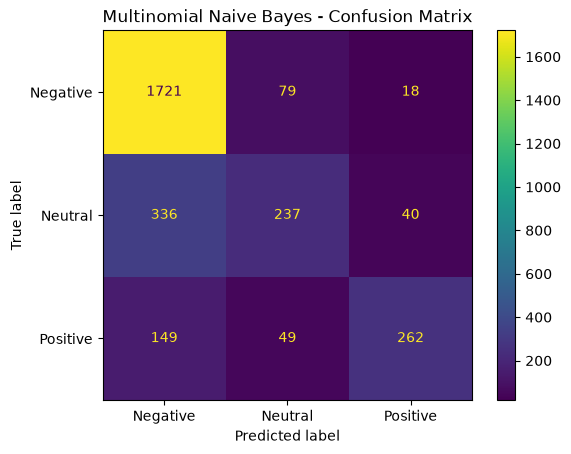

In [34]:
cm = confusion_matrix(y_test, y_pred_nb)
ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Negative", "Neutral", "Positive"]).plot()
plt.title("Multinomial Naive Bayes - Confusion Matrix")
plt.show()

### **SVM**

In [ ]:
param_grid = {"C": [0.01, 0.05, 0.1, 0.25, 0.5, 1, 2, 5, 10]}
svm_grid = GridSearchCV(LinearSVC(random_state=42),param_grid=param_grid,scoring="f1_macro",cv=5,n_jobs=1)
svm_grid.fit(x_train_tfidf, y_train)

print("Best C:", svm_grid.best_params_)
print("Best CV Macro-F1:", svm_grid.best_score_)

Best C: {'C': 0.5}
Best CV Macro-F1: 0.6993847838917991


Accuracy: 0.7903839501902455
Macro F1: 0.7189527079323726

Classification Report:

ROC_AUC SCORE: 0.8993931829983289
              precision    recall  f1-score   support

           0     0.8251    0.9186    0.8693      1818
           1     0.6456    0.4992    0.5630       613
           2     0.7863    0.6717    0.7245       460

    accuracy                         0.7904      2891
   macro avg     0.7523    0.6965    0.7190      2891
weighted avg     0.7809    0.7904    0.7813      2891



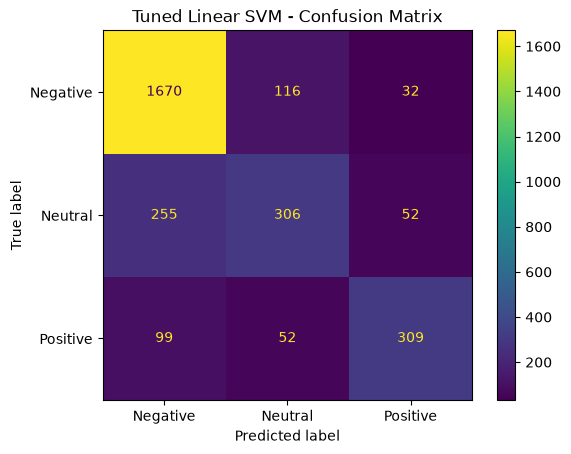

In [66]:
svm_model = svm_grid.best_estimator_

y_pred_svm = svm_model.predict(x_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Macro F1:", f1_score(y_test, y_pred_svm, average="macro"))

print("\nClassification Report:\n")
svm_score = svm_model.decision_function(x_test_tfidf)
svm_prob = np.exp(svm_score) / np.exp(svm_score).sum(axis=1, keepdims=True)
svm_auc = roc_auc_score(y_test, svm_prob, multi_class="ovr", average="macro")
print("ROC_AUC SCORE:", svm_auc)
print(classification_report(y_test, y_pred_svm, digits=4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=["Negative", "Neutral", "Positive"]
)

plt.title("Tuned Linear SVM - Confusion Matrix")
plt.show()

### **Random Forest**

In [56]:
param_dist = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [10, 20, 30, 40, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"]
}
rf_random = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42,n_jobs=-1),param_distributions=param_dist,
                               n_iter=30,scoring="f1_macro",cv=5,random_state=42,n_jobs=-1)
rf_random.fit(x_train_tfidf, y_train)
print("Best parameters:", rf_random.best_params_)
print("Best CV Macro-F1:", rf_random.best_score_)

Best parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 40, 'class_weight': 'balanced'}
Best CV Macro-F1: 0.6950285178353595


In [57]:
rf_model = rf_random.best_estimator_

Random Forest Training Accuracy: 0.8133
Random Forest Test Accuracy    : 0.7444

Testing metrices:
Macro F1: 0.7023
ROC_AUC SCORE: 0.8867251625935904

Classification Report:

              precision    recall  f1-score   support

           0     0.8977    0.7629    0.8249      1818
           1     0.5215    0.6737    0.5879       613
           2     0.6354    0.7652    0.6943       460

    accuracy                         0.7444      2891
   macro avg     0.6849    0.7340    0.7023      2891
weighted avg     0.7762    0.7444    0.7538      2891



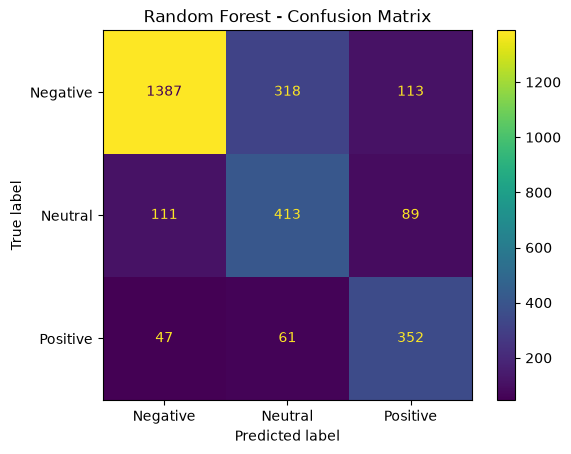

In [62]:
y_train_pred_rf = rf_model.predict(x_train_tfidf)
y_test_pred_rf = rf_model.predict(x_test_tfidf)

train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

print("Random Forest Training Accuracy:", round(train_accuracy_rf, 4))
print("Random Forest Test Accuracy    :", round(test_accuracy_rf, 4))

print("\nTesting metrices:")
print("Macro F1:", round(f1_score(y_test, y_test_pred_rf, average="macro"),4))
rf_prob = rf_model.predict_proba(x_test_tfidf)
rf_auc = roc_auc_score(y_test, rf_prob, multi_class="ovr", average="macro")
print("ROC_AUC SCORE:", rf_auc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred_rf, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test,y_test_pred_rf,display_labels=["Negative", "Neutral", "Positive"])
plt.title("Random Forest - Confusion Matrix")
plt.show()

### ML Models — Comparative Evaluation

| Metric | Multinomial Naive Bayes | Linear SVM | Random Forest |
|---|---:|---:|---:|
| **Test Accuracy** | 76.79% | **79.04%** | 74.44% |
| **Class 0 Precision** | 0.7801 | 0.8251 | **0.8977** |
| **Class 0 Recall** | **0.9466** | 0.9186 | 0.7629 |
| **Class 1 Precision** | **0.6493** | 0.6456 | 0.5215 |
| **Class 1 Recall** | 0.3866 | 0.4992 | **0.6737** |
| **Class 2 Precision** | **0.8187** | 0.7863 | 0.6354 |
| **Class 2 Recall** | 0.5696 | 0.6717 | **0.7652** |
| **Macro F1** | 0.6706 | **0.7190** | 0.7023 |
| **ROC-AUC** | 0.8891 | **0.8994** | 0.8867

**Conclusion:** **Linear SVM** provides the best overall performance, achieving the highest test accuracy, Macro-F1, and ROC-AUC.